In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('employees.csv')

# Display the first few rows to understand the data
df.head()

,EMPLOYEE_ID,FIRST_NAME,LAST_NAME,EMAIL,PHONE_NUMBER,HIRE_DATE,JOB_ID,SALARY,COMMISSION_PCT,MANAGER_ID,DEPARTMENT_ID
0,198,Donald,OConnell,DOCONNEL,650.507.9833,21-Jun-07,SH_CLERK,2600,-,124,50
1,199,Douglas,Grant,DGRANT,650.507.9844,13-Jan-08,SH_CLERK,2600,-,124,50
2,200,Jennifer,Whalen,JWHALEN,515.123.4444,17-Sep-03,AD_ASST,4400,-,101,10
3,201,Michael,Hartstein,MHARTSTE,515.123.5555,17-Feb-04,MK_MAN,13000,-,100,20
4,202,Pat,Fay,PFAY,603.123.6666,17-Aug-05,MK_REP,6000,-,201,20


In [2]:
# Check data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   EMPLOYEE_ID     50 non-null     int64 
 1   FIRST_NAME      50 non-null     object
 2   LAST_NAME       50 non-null     object
 3   EMAIL           50 non-null     object
 4   PHONE_NUMBER    50 non-null     object
 5   HIRE_DATE       50 non-null     object
 6   JOB_ID          50 non-null     object
 7   SALARY          50 non-null     int64 
 8   COMMISSION_PCT  50 non-null     object
 9   MANAGER_ID      50 non-null     object
 10  DEPARTMENT_ID   50 non-null     int64 
dtypes: int64(3), object(8)
memory usage: 4.4+ KB


In [3]:
# Select numeric columns for statistics (e.g., SALARY)
numeric_cols = df[['SALARY']]

print("--- Maximum Values ---")
print(numeric_cols.max())

print("\n--- Standard Deviation ---")
print(numeric_cols.std())

print("\n--- Covariance Matrix ---")
# If you had multiple numeric columns like age and salary, it would show covariance between them
print(numeric_cols.cov())

# Alternatively, basic summary statistics using describe
print("\n--- Summary Statistics (Describe) ---")
print(numeric_cols.describe())

--- Maximum Values ---
SALARY    24000
dtype: int64

--- Standard Deviation ---
SALARY    4586.181772
dtype: float64

--- Covariance Matrix ---
              SALARY
SALARY  2.103306e+07

--- Summary Statistics (Describe) ---
             SALARY
count     50.000000
mean    6182.320000
std     4586.181772
min     2100.000000
25%     2725.000000
50%     4600.000000
75%     8150.000000
max    24000.000000


In [4]:
# Grouping by a qualitative variable (DEPARTMENT_ID) to summarize a quantitative variable (SALARY)
print("--- Summary Statistics of Salary Grouped by Department ID ---")
grouped_stats = df.groupby('DEPARTMENT_ID')['SALARY'].describe()
print(grouped_stats)

--- Summary Statistics of Salary Grouped by Department ID ---
               count          mean          std      min      25%      50%  \
DEPARTMENT_ID                                                                
10               1.0   4400.000000          NaN   4400.0   4400.0   4400.0   
20               2.0   9500.000000  4949.747468   6000.0   7750.0   9500.0   
30               6.0   4150.000000  3362.588289   2500.0   2650.0   2850.0   
40               1.0   6500.000000          NaN   6500.0   6500.0   6500.0   
50              23.0   3721.739130  2007.249706   2100.0   2500.0   2800.0   
60               5.0   5760.000000  1925.616784   4200.0   4800.0   4800.0   
70               1.0  10000.000000          NaN  10000.0  10000.0  10000.0   
90               3.0  19333.333333  4041.451884  17000.0  17000.0  17000.0   
100              6.0   8601.333333  1804.131555   6900.0   7725.0   8000.0   
110              2.0  10154.000000  2621.951945   8300.0   9227.0  10154.0   

 

In [5]:
# Create a list that contains a numeric value for each response to the categorical variable
# We will encode 'JOB_ID' into numeric values using pandas factorize
df['JOB_ID_NUMERIC'], unique_jobs = pd.factorize(df['JOB_ID'])

# Convert the column into a python list as requested
encoded_job_list = df['JOB_ID_NUMERIC'].tolist()

print("Unique Job IDs mapping:\n", unique_jobs.tolist())
print("\nNumeric list for categorical variable (First 20 items):\n", encoded_job_list[:20])

Unique Job IDs mapping:
 ['SH_CLERK', 'AD_ASST', 'MK_MAN', 'MK_REP', 'HR_REP', 'PR_REP', 'AC_MGR', 'AC_ACCOUNT', 'AD_PRES', 'AD_VP', 'IT_PROG', 'FI_MGR', 'FI_ACCOUNT', 'PU_MAN', 'PU_CLERK', 'ST_MAN', 'ST_CLERK']

Numeric list for categorical variable (First 20 items):
 [0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 9, 10, 10, 10, 10, 10, 11, 12, 12]


In [6]:
# Group by JOB_ID and get the count of employees in each role
job_id_counts = df.groupby('JOB_ID').size().reset_index(name='Employee_Count')

# Alternatively, value_counts() is often used: df['JOB_ID'].value_counts()
print("--- Employee Count per JOB_ID ---")
print(job_id_counts)

--- Employee Count per JOB_ID ---
        JOB_ID  Employee_Count
0   AC_ACCOUNT               1
1       AC_MGR               1
2      AD_ASST               1
3      AD_PRES               1
4        AD_VP               2
5   FI_ACCOUNT               5
6       FI_MGR               1
7       HR_REP               1
8      IT_PROG               5
9       MK_MAN               1
10      MK_REP               1
11      PR_REP               1
12    PU_CLERK               5
13      PU_MAN               1
14    SH_CLERK               2
15    ST_CLERK              16
16      ST_MAN               5


C:\Users\hp\AppData\Local\Temp\ipykernel_6664\781776460.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='JOB_ID', data=df, order=df['JOB_ID'].value_counts().index, palette='viridis', ax=axes[1])


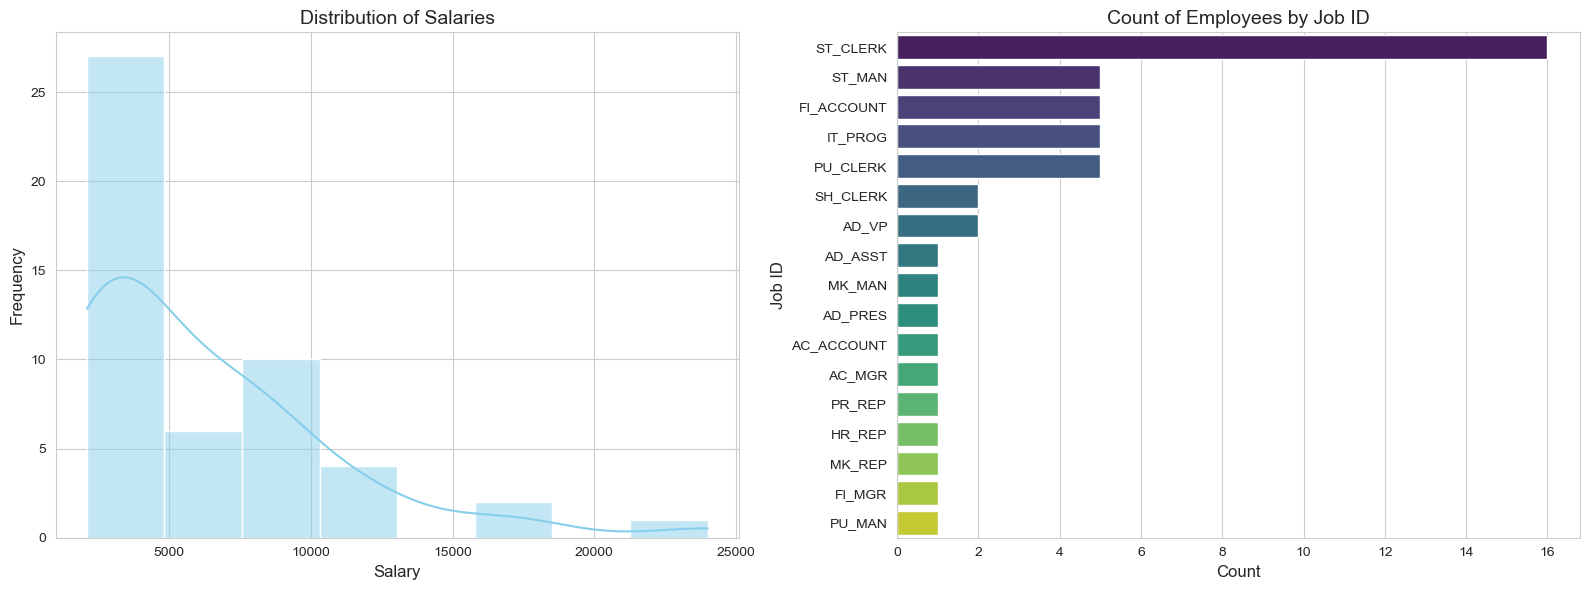

In [7]:
# Set the plot style
sns.set_style("whitegrid")

# Create a figure with two subplots (1 Histogram, 1 Bar chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Visualization of Quantitative Column (SALARY)
sns.histplot(df['SALARY'], kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Salaries', fontsize=14)
axes[0].set_xlabel('Salary', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# 2. Visualization of Qualitative Column (JOB_ID Counts)
sns.countplot(y='JOB_ID', data=df, order=df['JOB_ID'].value_counts().index, palette='viridis', ax=axes[1])
axes[1].set_title('Count of Employees by Job ID', fontsize=14)
axes[1].set_xlabel('Count', fontsize=12)
axes[1].set_ylabel('Job ID', fontsize=12)

# Adjust layout and show
plt.tight_layout()
plt.show()